# Validation of simulations: comparing with gene trees from Stiller 2024

In [219]:
import tskit
import random
import pandas as pd
import sys

In [220]:
def sample_genetrees(tsdir, rep, ns, nt):
    sampled_gtrees_l = []
    for i in range(ns):
        ts = tskit.load(f"../simulated_treeseq/{rep}-{i+1}.ts")
        table = ts.dump_tables()
        nd_to_pop = {}
        for name, nd in enumerate(table.nodes):
            nd_to_pop[name] = table.populations[nd.population].metadata["name"]
        for j in range(0, ts.get_num_trees(), int(ts.get_num_trees() / nt * ns)):
            sampled_gtrees_l.append(ts.at(j).as_newick(node_labels=nd_to_pop))
    return sampled_gtrees_l

## Comparing pairwise distance between taxa across gene trees

In [224]:
%%bash
export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/home/asapci/lib
mkdir -p ../misc/simulated_true_gtrees_pwdist/
mkdir -p ../misc/real_inferred_gtrees_pwdist/
mkdir -p ../misc/simulated_inferred_gtrees_pwdist/
seq 1 32 | xargs -I{} -t -P32 bash -c "nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r{}.txt"
seq 1 32 | xargs -I{} -t -P32 bash -c "nw_distance -n -s f -mm  <(shuf ../simulated_genetrees/default-500Kb.gtrees  | head -1) > ../misc/simulated_true_gtrees_pwdist/r{}.txt"
seq 1 32 | xargs -I{} -t -P32 bash -c "nw_distance -n -s f -mm  <(shuf ../gene_trees-Stiller2024.nwk  | head -1 | cut -f2) > ../misc/stiller2024_inferred_gtrees_pwdist/r{}.txt"

bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r1.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r2.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r3.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r4.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r5.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred_genetrees/concat-default.gtrees | head -1 | cut -f2) > ../misc/simulated_inferred_gtrees_pwdist//r6.txt'
bash -c 'nw_distance -n -s f -mm  <(shuf ../inferred

In [225]:
mean_srate = 1.908590331970381e-08

In [226]:
def df_mean_pwdist(path, n=32):
    df_l = []
    for i in range(n):
        df = pd.read_csv(f"{path}/r{i+1}.txt", sep="\t", index_col=0)
        df = df.reindex(sorted(df.columns), axis=1).sort_index()
        # df["r"] = i+1
        df_l.append(df)
    df = pd.concat(df_l)
    df = df.groupby(level=0).mean()
    return df

In [227]:
df_st = df_mean_pwdist("../misc/simulated_true_gtrees_pwdist/") * mean_srate
df_se = df_mean_pwdist("../misc/simulated_inferred_gtrees_pwdist/")
df_si = df_mean_pwdist("../misc/stiller2024_inferred_gtrees_pwdist/")

In [228]:
index = list(set(df_st.index).intersection(set(df_si.index)))
columns = list(set(df_st.columns).intersection(set(df_si.columns)))

In [229]:
df = (df_st.loc[index][columns] - df_si.loc[index][columns]) / df_si.loc[index][columns]
df.to_csv("../results/pairwise_dist-simulated_vs_stiller.tsv", sep="\t")

In [230]:
df = (df_se.loc[index][columns] - df_si.loc[index][columns]) / df_si.loc[index][columns]
df.to_csv("../results/pairwise_dist-inferred_vs_stiller.tsv", sep="\t")

## Comparing QQS distributions

In [210]:
PHLAG_PATH = "../../../phlag"
sys.path.append(PHLAG_PATH)
from qqs import QQS, MSC
import utils
import treeswift
import jax.numpy as jnp

In [211]:
species_tree_path = "../main_neoaves-num_generations.tre"
species_tree = utils.label_tree(treeswift.read_tree_newick(species_tree_path))

In [213]:
gene_trees_path_st = "../simulated_genetrees/default-500Kb.gtrees"
with open(gene_trees_path_st, "r") as f:
    gene_trees_st = [treeswift.read_tree_newick(line.strip()) for line in f]

In [214]:
gene_trees_path_se = "../inferred_genetrees/concat-default.gtrees"
with open(gene_trees_path_se, "r") as f:
    gene_trees_se = [treeswift.read_tree_newick(line.strip()) for line in f]

In [59]:
%%bash
shuf ../gene_trees-Stiller2024.nwk | head -2000 | cut -f2 > ../gene_trees-subsampled2000-Stiller2024.nwk

In [61]:
gene_trees_path_si = "../gene_trees-subsampled2000-Stiller2024.nwk"
with open(gene_trees_path_si, "r") as f:
    gene_trees_si = [ts.read_tree_newick(line.strip()) for line in f]

In [62]:
msc_se = MSC(species_tree, gene_trees_se)
msc_st = MSC(species_tree, gene_trees_st)
msc_si = MSC(species_tree, gene_trees_si)

In [64]:
label_to_freqs_st = msc_st.compute_qqs_freqs()
label_to_freqs_si = msc_si.compute_qqs_freqs()
label_to_freqs_se = msc_se.compute_qqs_freqs()

In [217]:
df_qqs_st = pd.DataFrame(
    map(lambda x: jnp.nanmean(x, axis=0), label_to_freqs_st.values()),
    index=label_to_freqs_st.keys(),
    columns=["t1", "t2", "t3"],
)
df_qqs_si = pd.DataFrame(
    map(lambda x: jnp.nanmean(x, axis=0), label_to_freqs_si.values()),
    index=label_to_freqs_si.keys(),
    columns=["t1", "t2", "t3"],
)
df_qqs_se = pd.DataFrame(
    map(lambda x: jnp.nanmean(x, axis=0), label_to_freqs_se.values()),
    index=label_to_freqs_se.keys(),
    columns=["t1", "t2", "t3"],
)

In [218]:
df_qqs_st.to_csv("../results/qqs_dist-simulated_true.tsv", sep="\t")
df_qqs_si.to_csv("../results/qqs_dist-inferred_stiller.tsv", sep="\t")
df_qqs_se.to_csv("../results/qqs_dist-simulated_inferred.tsv", sep="\t")

## Inspecting the effect of recombination suppression on Neoaves branch

In [77]:
%%bash
mkdir -p ../tmp/simulated_treeseq/ # to be removed
population="N721"
name="recombination_suppression-${population}"

for i in {1..100}; do
    python ../simulate_treeseq.py  -i ../main-num_generations.tre \
        -p ../population-sizes.tsv -s ../substitution-units.tsv -g ../num-generations.tsv \
        --recombination-rate-change 10 --parameter-change-population ${population} \
        -o ../tmp/simulated_treeseq/anomaly_case-${name}-10Kb-$i.ts -l 10000 --seed $i >/dev/null 2>&1 &
done

In [78]:
import dendropy
import tskit
import matplotlib.pyplot as plt

population = "N721"

tns = dendropy.TaxonNamespace()
st = dendropy.Tree.get(
    path="../main-num_generations.tre",
    schema="newick",
    preserve_underscores=True,
    taxon_namespace=tns,
)
st.encode_bipartitions()
nd = st.find_node_with_label(population)
edge = nd.edge

In [83]:
bps_l = []
name = f"recombination_suppression-{population}"
for ix in range(1, 100):
    ts = tskit.load(f"../tmp/simulated_treeseq/anomaly_case-{name}-10Kb-{ix}.ts")
    tables = ts.dump_tables()
    nd_to_pop = {}
    for pop, nd in enumerate(tables.nodes):
        nd_to_pop[pop] = tables.populations[nd.population].metadata["name"]

    bp_l = []
    for i in range(0, ts.num_trees, 400):
        gt = dendropy.Tree.get(
            data=ts.at(i).as_newick(node_labels=nd_to_pop),
            schema="newick",
            preserve_underscores=True,
            taxon_namespace=tns,
        )
        bp_l.append(gt.is_compatible_with_bipartition(edge.bipartition))
    bps_l.append(sum(bp_l) / len(bp_l))

Text(0, 0.5, 'Count')

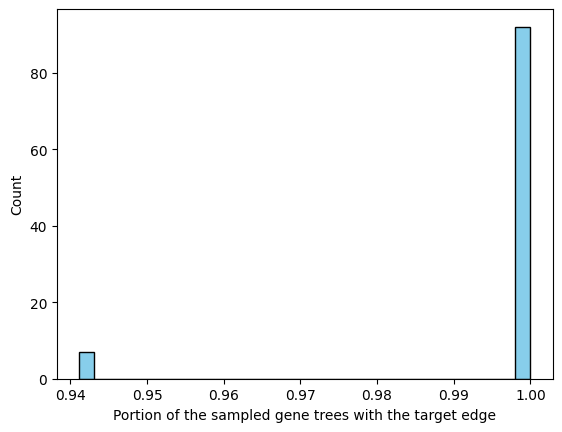

In [84]:
r = plt.hist(bps_l, density=False, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Portion of the sampled gene trees with the target edge")
plt.ylabel("Count")

In [76]:
%%bash
rm -r ../tmp/simulated_treeseq/